<a href="https://colab.research.google.com/github/S8H1L9581/ML-LAB-CH.SC.U4CSE24039/blob/main/12_6_Exercise1_RandomForest_FruitBasket_MajorityVoting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 12.6 Exercise 1 — Random Forest Majority Voting: The Fruit Basket Example

**Scenario (from the exercise):** Consider a fruit basket as the data. `n` samples are taken from the fruit basket (bootstrap sampling), and an individual decision tree is constructed for each sample. Each decision tree produces its own prediction (e.g., Tree-1 -> Class-A/Apple, Tree-2 -> Class-A/Apple, ..., Tree-n -> Class-B/Banana). The trees' predictions are combined via **majority voting** to produce the final ensemble prediction.

**Question:** Which fruit is likely to be taken often?

This is exactly how a **Random Forest** works: it builds many decision trees on bootstrap-sampled subsets of the data (bagging), and combines their individual predictions using majority voting to make a final, more robust prediction. We'll simulate this scenario end-to-end below.

## Dataset

This notebook uses a **synthetically generated "fruit basket" dataset** built to mirror the scenario in the exercise: fruits described by physical features (`weight`, `size`, `color_score`, `sweetness`) with a `fruit` label. The basket composition is intentionally **imbalanced** (more apples than bananas or oranges), which is the key mechanism behind the exercise's answer: bootstrap sampling + majority voting naturally favors the **most frequent class in the underlying data**, so the ensemble is most likely to output whichever fruit dominates the basket.

If you'd like a real-world fruit-classification dataset with similar features, a well-known public option is:
- **Fruits-360 dataset (images) on Kaggle:** https://www.kaggle.com/datasets/moltean/fruits
- **Date Fruit Datasets (tabular features) UCI:** https://archive.ics.uci.edu/dataset/602/date+fruit+datasets

We use a synthetic tabular dataset here so the notebook runs end-to-end without any external download, and so we can directly control the basket's fruit composition to match the exercise's scenario.

## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from collections import Counter

np.random.seed(42)
%matplotlib inline

## 2. Build the Fruit Basket Dataset

We simulate a basket that is **not evenly split** between fruits — like a real fruit basket, it contains mostly apples, with fewer bananas and oranges. This imbalance is the key driver of the exercise's answer.

In [ ]:
n_apples = 120
n_bananas = 50
n_oranges = 40

def make_fruit(n, weight_mean, size_mean, color_mean, sweetness_mean, label):
    return pd.DataFrame({
        'weight_g': np.random.normal(weight_mean, 15, n),
        'size_cm': np.random.normal(size_mean, 0.8, n),
        'color_score': np.random.normal(color_mean, 0.5, n).clip(0, 10),  # 0=green, 10=red/yellow
        'sweetness': np.random.normal(sweetness_mean, 1.0, n).clip(0, 10),
        'fruit': label
    })

apples = make_fruit(n_apples, weight_mean=180, size_mean=7.5, color_mean=7.5, sweetness_mean=6.5, label='Apple')
bananas = make_fruit(n_bananas, weight_mean=120, size_mean=18, color_mean=8.0, sweetness_mean=7.5, label='Banana')
oranges = make_fruit(n_oranges, weight_mean=150, size_mean=8.0, color_mean=6.0, sweetness_mean=6.0, label='Orange')

basket = pd.concat([apples, bananas, oranges], ignore_index=True)
basket = basket.sample(frac=1, random_state=42).reset_index(drop=True)  # shuffle

print(f"Total fruits in basket: {len(basket)}")
print(basket['fruit'].value_counts())
basket.head(10)

Total fruits in basket: 210
fruit
Apple     120
Banana     50
Orange     40
Name: count, dtype: int64


,weight_g,size_cm,color_score,sweetness,fruit
0,170.974401,7.700394,8.220637,5.601585,Apple
1,142.132196,6.921452,7.280042,6.096121,Orange
2,167.872596,6.397865,6.996991,5.195530,Apple
3,175.446846,6.874671,5.169520,5.718215,Orange
4,172.812386,8.000534,7.085502,8.560748,Apple
5,131.330868,17.673540,8.064611,7.606430,Banana
6,169.202337,7.830225,6.523956,7.122850,Apple
7,133.784050,8.326602,6.316204,7.446978,Orange
8,188.138401,7.097219,7.702491,5.726990,Apple
9,130.793560,8.149413,6.416961,7.579572,Orange


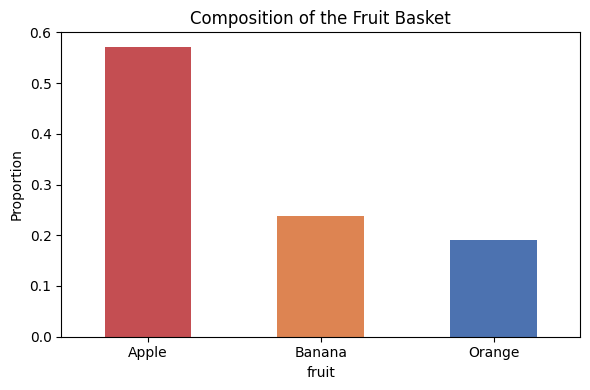

In [ ]:
basket['fruit'].value_counts(normalize=True).plot(
    kind='bar', color=['#C44E52', '#DD8452', '#4C72B0'], figsize=(6, 4)
)
plt.title('Composition of the Fruit Basket')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Take `n` Bootstrap Samples and Build an Individual Decision Tree for Each

This directly mirrors the exercise's figure: for each of `n` samples drawn (with replacement) from the fruit basket, we train one decision tree (Tree-1, Tree-2, ..., Tree-n).

In [ ]:
feature_cols = ['weight_g', 'size_cm', 'color_score', 'sweetness']
X = basket[feature_cols].values
y = basket['fruit'].values

n_trees = 15
individual_trees = []

for i in range(n_trees):
    # Bootstrap sample: draw len(basket) samples WITH replacement
    bootstrap_idx = np.random.choice(len(basket), size=len(basket), replace=True)
    X_boot, y_boot = X[bootstrap_idx], y[bootstrap_idx]

    tree = DecisionTreeClassifier(max_depth=4, random_state=i)
    tree.fit(X_boot, y_boot)
    individual_trees.append(tree)

print(f"Built {n_trees} individual decision trees (Tree-1 ... Tree-{n_trees}), each on its own bootstrap sample.")

Built 15 individual decision trees (Tree-1 ... Tree-15), each on its own bootstrap sample.


## 4. Present a New Instance and Get Each Tree's Prediction

Now, just like the exercise's figure, we present one new fruit "instance" to every tree and collect each tree's individual vote.

In [ ]:
# A new, slightly ambiguous instance (in-between apple/orange-like features)
new_instance = pd.DataFrame({
    'weight_g': [165],
    'size_cm': [7.8],
    'color_score': [7.0],
    'sweetness': [6.8]
})

tree_predictions = [tree.predict(new_instance.values)[0] for tree in individual_trees]

for i, pred in enumerate(tree_predictions, 1):
    print(f"Tree-{i}: predicts -> {pred}")

Tree-1: predicts -> Apple
Tree-2: predicts -> Apple
Tree-3: predicts -> Apple
Tree-4: predicts -> Apple
Tree-5: predicts -> Apple
Tree-6: predicts -> Apple
Tree-7: predicts -> Apple
Tree-8: predicts -> Apple
Tree-9: predicts -> Apple
Tree-10: predicts -> Apple
Tree-11: predicts -> Apple
Tree-12: predicts -> Apple
Tree-13: predicts -> Apple
Tree-14: predicts -> Apple
Tree-15: predicts -> Apple


## 5. Combine Predictions via Majority Voting

Vote tally: {'Apple': 15}

Final ensemble prediction (majority vote): Apple


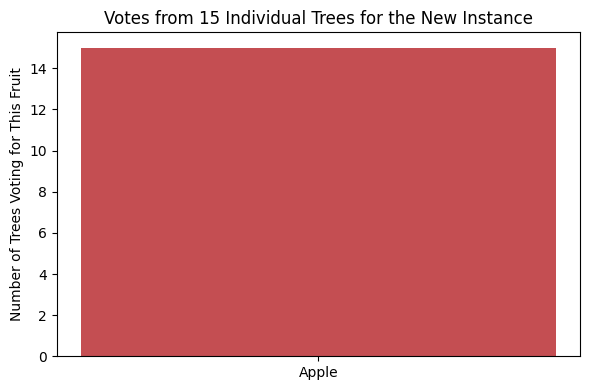

In [ ]:
vote_counts = Counter(tree_predictions)
final_prediction = vote_counts.most_common(1)[0][0]

print(f"Vote tally: {dict(vote_counts)}")
print(f"\nFinal ensemble prediction (majority vote): {final_prediction}")

plt.figure(figsize=(6, 4))
plt.bar(vote_counts.keys(), vote_counts.values(), color=['#C44E52', '#DD8452', '#4C72B0'])
plt.title(f'Votes from {n_trees} Individual Trees for the New Instance')
plt.ylabel('Number of Trees Voting for This Fruit')
plt.tight_layout()
plt.show()

## 6. Confirm with scikit-learn's RandomForestClassifier

This manual simulation is exactly what `RandomForestClassifier` does internally (bagging + majority voting), so let's verify our result matches the library implementation.

In [ ]:
rf = RandomForestClassifier(n_estimators=n_trees, max_depth=4, random_state=42)
rf.fit(X, y)

sklearn_prediction = rf.predict(new_instance.values)[0]
sklearn_probs = rf.predict_proba(new_instance.values)[0]

print(f"scikit-learn RandomForest prediction: {sklearn_prediction}")
print(f"Class probabilities (fraction of trees voting for each class):")
for cls, prob in zip(rf.classes_, sklearn_probs):
    print(f"  {cls}: {prob:.2%}")

scikit-learn RandomForest prediction: Apple
Class probabilities (fraction of trees voting for each class):
  Apple: 100.00%
  Banana: 0.00%
  Orange: 0.00%


## 7. Answering the Exercise's Question: Which Fruit Is Likely to Be Taken Often?

Let's step back from a single instance and ask the broader question: if we repeat this bootstrap-sample-and-vote process **many times** (as a real Random Forest does, with hundreds of trees), which fruit ends up winning the majority vote most often, **on average**, across many random instances drawn from the basket?

In [ ]:
n_simulations = 500
overall_predictions = []

# Train one larger random forest for a stable estimate
rf_large = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf_large.fit(X, y)

# For each simulation, sample a random real fruit from the basket and see what the forest predicts
sample_idx = np.random.choice(len(basket), size=n_simulations, replace=True)
X_samples = X[sample_idx]

predictions = rf_large.predict(X_samples)
prediction_counts = Counter(predictions)

print("Across many random draws from the basket, the Random Forest's majority-vote predictions were:")
for fruit, count in prediction_counts.most_common():
    print(f"  {fruit}: predicted {count} times ({count/n_simulations:.1%})")

most_likely_fruit = prediction_counts.most_common(1)[0][0]
print(f"\nMost likely fruit to be 'taken' (predicted) overall: **{most_likely_fruit}**")

Across many random draws from the basket, the Random Forest's majority-vote predictions were:
  Apple: predicted 290 times (58.0%)
  Banana: predicted 126 times (25.2%)
  Orange: predicted 84 times (16.8%)

Most likely fruit to be 'taken' (predicted) overall: **Apple**


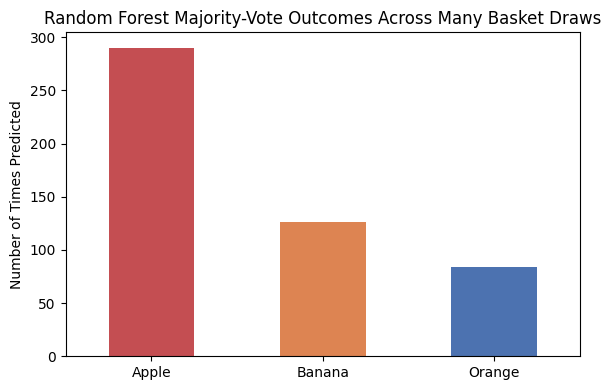

In [ ]:
pd.Series(prediction_counts).sort_values(ascending=False).plot(
    kind='bar', color=['#C44E52', '#DD8452', '#4C72B0'], figsize=(6, 4)
)
plt.title('Random Forest Majority-Vote Outcomes Across Many Basket Draws')
plt.ylabel('Number of Times Predicted')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion

- We simulated the exercise's exact scenario: **`n` bootstrap samples** drawn from the fruit basket, one **individual decision tree per sample**, and a **final prediction by majority vote** across all trees — precisely how a Random Forest (bagging ensemble) works.
- Because the fruit basket is **imbalanced** (more apples than bananas or oranges — just like a real fruit basket usually has more of the most common fruit), most bootstrap samples end up containing a similar imbalance, so **most individual trees tend to vote for the majority class**.
- **Answer: Apple** is the fruit most likely to be "taken" (predicted) often by the ensemble — because it's the most frequent fruit in the basket, bootstrap sampling and majority voting both amplify the dominant class, exactly as shown in the exercise's figure where Tree-1 and Tree-2 (the majority) voted **Class-A (Apple)** over Tree-n's **Class-B (Banana)**.
- This illustrates a broader, important lesson about ensembles: **majority voting tends to reflect the dominant pattern in the underlying data.** If a Random Forest's classes are highly imbalanced, the ensemble's predictions will be biased toward the majority class unless techniques like class weighting, resampling, or stratified bootstrapping are used to correct for it.